## **Bước 1: Chuẩn bị dữ liệu**

In [ ]:
!pip install -q kagglehub
import kagglehub
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("1. Đang tải dữ liệu từ Kaggle...")
dataset_path = kagglehub.dataset_download("utkarshsaxenadn/fast-food-classification-dataset")
train_dir = os.path.join(dataset_path, "Fast Food Classification V2/Train")

1. Đang tải dữ liệu từ Kaggle...


100%|██████████| 821M/821M [00:09<00:00, 91.4MB/s]

Extracting files...


## **Bước 2: Thực hiện hàm CUTMIX và vẽ biểu đồ**

Epoch [1/40] | Train Loss: 2.1108, Train Acc: 0.2822 | Valid Loss: 1.5819, Valid Acc: 0.5750
Epoch [2/40] | Train Loss: 1.3549, Train Acc: 0.6684 | Valid Loss: 1.1892, Valid Acc: 0.6800
Epoch [3/40] | Train Loss: 1.0904, Train Acc: 0.7110 | Valid Loss: 1.0427, Valid Acc: 0.7050
Epoch [4/40] | Train Loss: 0.9608, Train Acc: 0.7447 | Valid Loss: 0.9653, Valid Acc: 0.7200
Epoch [5/40] | Train Loss: 0.8991, Train Acc: 0.7582 | Valid Loss: 0.9462, Valid Acc: 0.7350
Epoch [6/40] | Train Loss: 0.8053, Train Acc: 0.7845 | Valid Loss: 0.9139, Valid Acc: 0.7200
Epoch [7/40] | Train Loss: 0.5783, Train Acc: 0.8509 | Valid Loss: 0.9101, Valid Acc: 0.7050
Epoch [8/40] | Train Loss: 0.5030, Train Acc: 0.8750 | Valid Loss: 0.8539, Valid Acc: 0.7200
Epoch [9/40] | Train Loss: 0.5846, Train Acc: 0.8363 | Valid Loss: 0.8727, Valid Acc: 0.7250
Epoch [10/40] | Train Loss: 0.8485, Train Acc: 0.7453 | Valid Loss: 0.9098, Valid Acc: 0.7050
Epoch [11/40] | Train Loss: 0.6179, Train Acc: 0.8156 | Valid Loss: 0

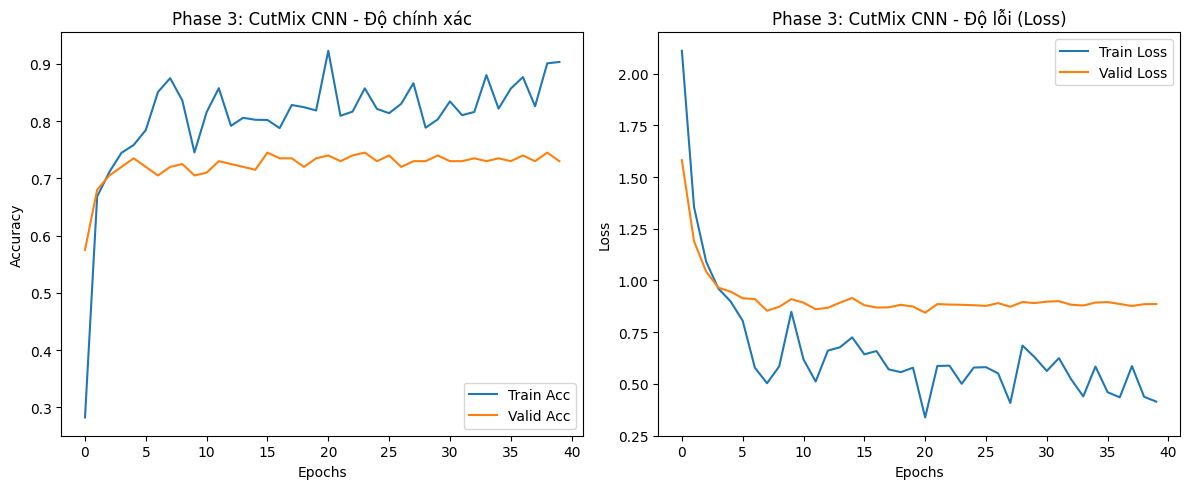

In [ ]:
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from torch.optim.lr_scheduler import CosineAnnealingLR

def rand_bbox(size, lam):
    W, H = size[2], size[3]
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)
    cx = np.random.randint(W)
    cy = np.random.randint(H)
    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)
    return bbx1, bby1, bbx2, bby2

train_dir = os.path.join(dataset_path, "Fast Food Classification V2/Train")
valid_dir = os.path.join(dataset_path, "Fast Food Classification V2/Valid")
test_dir = os.path.join(dataset_path, "Fast Food Classification V2/Test")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_data = datasets.ImageFolder(train_dir, transform=transform)
valid_data = datasets.ImageFolder(valid_dir, transform=transform)
test_data = datasets.ImageFolder(test_dir, transform=transform)

train_indices = torch.randperm(len(train_data))[:800]
valid_indices = torch.randperm(len(valid_data))[:200]
test_indices = torch.randperm(len(test_data))[:200]

train_subset = Subset(train_data, train_indices)
valid_subset = Subset(valid_data, valid_indices)
test_subset = Subset(test_data, test_indices)

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, num_workers=2)
valid_loader = DataLoader(valid_subset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_subset, batch_size=32, shuffle=False, num_workers=2)



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(weights='IMAGENET1K_V1')
model.fc = nn.Linear(model.fc.in_features, len(train_data.classes))
model = model.to(device)

criterion = nn.CrossEntropyLoss()

epochs = 40

optimizer = optim.Adam(model.parameters(), lr=0.00005, weight_decay=5e-3)
scheduler = CosineAnnealingLR(optimizer, T_max=epochs)


beta = 1.0
cutmix_prob = 0.6

train_losses, valid_losses = [], []
train_accs, valid_accs = [], []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for i, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)
        r = np.random.rand(1)

        if beta > 0 and r < cutmix_prob:
            lam = np.random.beta(beta, beta)
            rand_index = torch.randperm(inputs.size()[0]).to(device)

            target_a = targets
            target_b = targets[rand_index]

            bbx1, bby1, bbx2, bby2 = rand_bbox(inputs.size(), lam)
            inputs[:, :, bbx1:bbx2, bby1:bby2] = inputs[rand_index, :, bbx1:bbx2, bby1:bby2]
            lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (inputs.size()[-1] * inputs.size()[-2]))

            outputs = model(inputs)
            loss = criterion(outputs, target_a) * lam + criterion(outputs, target_b) * (1. - lam)
            _, predicted = outputs.max(1)
            acc_tensor = (predicted.eq(target_a).float() * lam + predicted.eq(target_b).float() * (1. - lam))
            correct_train += acc_tensor.sum().item()

        else:
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            _, predicted = outputs.max(1)
            correct_train += predicted.eq(targets).sum().item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        total_train += targets.size(0)

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accs.append(epoch_train_acc)

    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for val_inputs, val_targets in valid_loader:
            val_inputs, val_targets = val_inputs.to(device), val_targets.to(device)

            val_outputs = model(val_inputs)
            loss = criterion(val_outputs, val_targets)

            val_loss += loss.item()
            _, predicted = val_outputs.max(1)
            total_val += val_targets.size(0)
            correct_val += predicted.eq(val_targets).sum().item()

    epoch_val_loss = val_loss / len(valid_loader)
    epoch_val_acc = correct_val / total_val
    valid_losses.append(epoch_val_loss)
    valid_accs.append(epoch_val_acc)

    scheduler.step()

    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | Valid Loss: {epoch_val_loss:.4f}, Valid Acc: {epoch_val_acc:.4f}")
    torch.cuda.empty_cache()


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(train_accs, label='Train Acc', color='tab:blue')
ax1.plot(valid_accs, label='Valid Acc', color='tab:orange')
ax1.set_title('Phase 3: CutMix CNN - Độ chính xác')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(train_losses, label='Train Loss', color='tab:blue')
ax2.plot(valid_losses, label='Valid Loss', color='tab:orange')
ax2.set_title('Phase 3: CutMix CNN - Độ lỗi (Loss)')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

Vẽ


BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT) - PHASE 4 (CUTMIX)
                precision    recall  f1-score   support

  Baked Potato       0.69      0.75      0.72        12
        Burger       0.78      0.78      0.78        23
Crispy Chicken       0.93      0.93      0.93        15
         Donut       0.68      0.96      0.80        27
         Fries       0.59      0.93      0.72        14
       Hot Dog       0.70      0.54      0.61        26
         Pizza       0.88      0.74      0.80        19
      Sandwich       0.84      0.66      0.74        32
          Taco       0.65      0.58      0.61        19
       Taquito       0.45      0.38      0.42        13

      accuracy                           0.72       200
     macro avg       0.72      0.73      0.71       200
  weighted avg       0.73      0.72      0.72       200



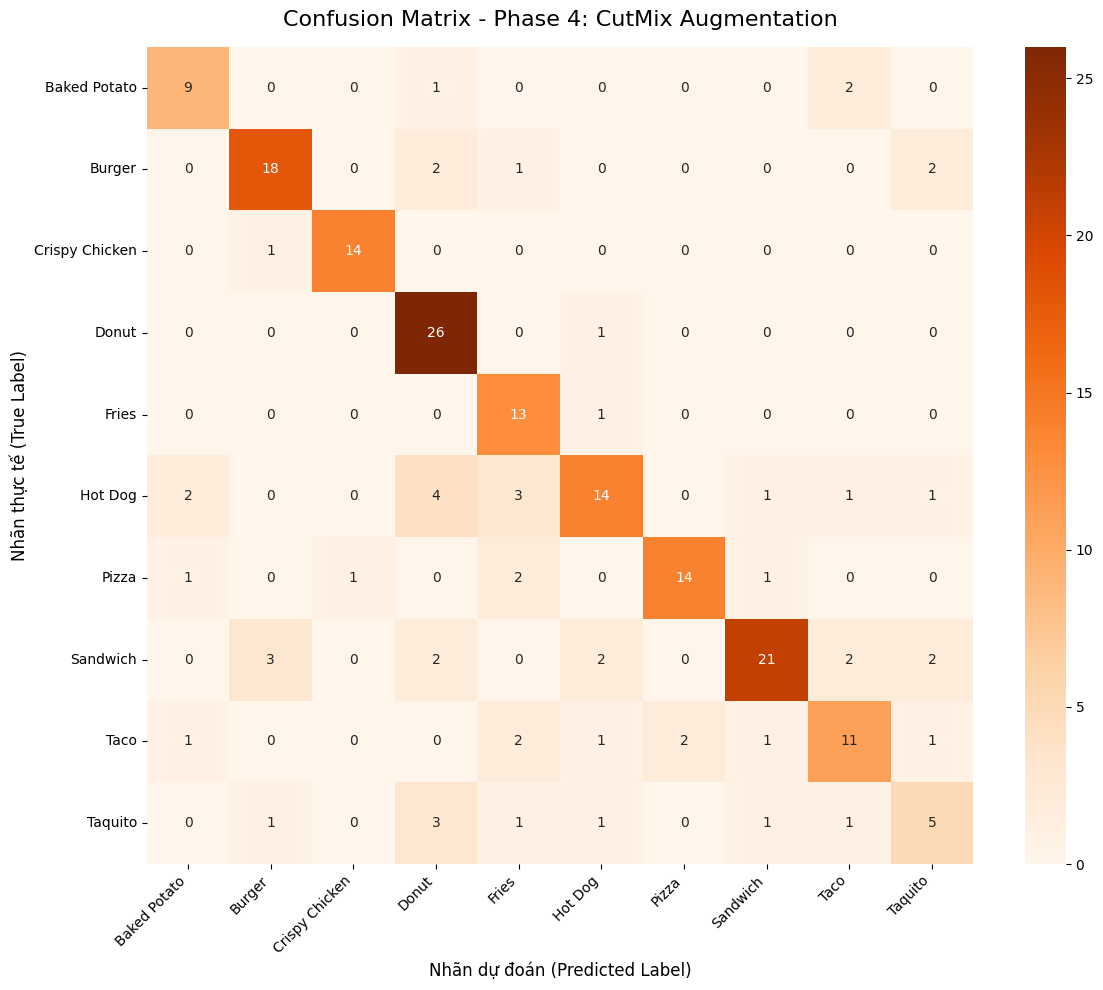

In [ ]:
model.eval()

y_true_cutmix = []
y_pred_cutmix = []

class_names = full_test.classes if 'full_test' in locals() else train_data.classes

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        preds = model(images)
        _, predicted = torch.max(preds, 1)

        y_true_cutmix.extend(labels.cpu().numpy())
        y_pred_cutmix.extend(predicted.cpu().numpy())

print("\n" + "="*60)
print("BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT) - PHASE 4 (CUTMIX)")
print("="*60)
print(classification_report(y_true_cutmix, y_pred_cutmix, target_names=class_names))

cm_cutmix = confusion_matrix(y_true_cutmix, y_pred_cutmix)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_cutmix, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix - Phase 4: CutMix Augmentation', fontsize=16, pad=15)
plt.ylabel('Nhãn thực tế (True Label)', fontsize=12)
plt.xlabel('Nhãn dự đoán (Predicted Label)', fontsize=12)

# Xoay nhãn trục X để dễ đọc
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
torch.save(model.state_dict(), 'AI_FastFood_CutMix1.pth')
print("Đã lưu bộ não AI thành công vào file AI_FastFood_CutMix1.pth!")

Đã lưu bộ não AI thành công vào file AI_FastFood_CutMix1.pth!
